In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# prepare
---

In [3]:
df = pd.read_csv("../data/gpu_1986-2026.csv", usecols=["Brand", "Name", "Graphics Card__Release Date", "Memory__Memory Size"])
df.head()

,Brand,Name,Graphics Card__Release Date,Memory__Memory Size
0,ATI,Color Emulation Card,"Aug 4th, 1986",32 KB
1,ATI,Graphics Solution,"Sep 22nd, 1986",64 KB
2,ATI,EGA Wonder 800,"Nov 16th, 1987",256 KB
3,ATI,Graphics Solution Plus,"Mar 23rd, 1987",64 KB
4,ATI,VGA Improved Performance,"Sep 28th, 1987",256 KB


# clean
---

In [4]:
# CHANGE COLUMN NAMES

column_namechange = {
    "Graphics Card__Release Date": "Date",
    "Memory__Memory Size": "Memory"
}

for old, new in column_namechange.items():
    df[new] = df[old]
    df = df.drop(columns=[old])
df

,Brand,Name,Date,Memory
0,ATI,Color Emulation Card,"Aug 4th, 1986",32 KB
1,ATI,Graphics Solution,"Sep 22nd, 1986",64 KB
2,ATI,EGA Wonder 800,"Nov 16th, 1987",256 KB
3,ATI,Graphics Solution Plus,"Mar 23rd, 1987",64 KB
4,ATI,VGA Improved Performance,"Sep 28th, 1987",256 KB
...,...,...,...,...
3198,XGI,Volari V5 Ultra,"Sep 15th, 2003",256 MB
3199,XGI,Volari V8,"Sep 15th, 2003",256 MB
3200,XGI,Volari V8,"Sep 15th, 2003",256 MB
3201,XGI,Volari V8 Ultra,"Sep 15th, 2003",256 MB


In [5]:
# DROP NA DATE & MEMORY

df = df.dropna(subset=["Date"]).copy()
df = df.dropna(subset=["Memory"]).copy()

In [6]:
# MEMORY IN GB COLUMN

multipliers = {"GB": 1, "MB": 1/1024, "KB": 1/1024**2}

tmp = df["Memory"].str.extract(r"(?i)(\d+)\s*(GB|MB|KB)")

tmp[0] = tmp[0].astype(float)

tmp[1] = tmp[1].map(multipliers)

df["Memory_inGB"] = tmp[0] * tmp[1]


In [7]:
# PARSING DATE 
# ADD YEAR COLUMN

df["Date"] = pd.to_datetime(df["Date"], format="mixed")
df["Year"] = df["Date"].dt.year

df

,Brand,Name,Date,Memory,Memory_inGB,Year
0,ATI,Color Emulation Card,1986-08-04,32 KB,0.000031,1986
1,ATI,Graphics Solution,1986-09-22,64 KB,0.000061,1986
2,ATI,EGA Wonder 800,1987-11-16,256 KB,0.000244,1987
3,ATI,Graphics Solution Plus,1987-03-23,64 KB,0.000061,1987
4,ATI,VGA Improved Performance,1987-09-28,256 KB,0.000244,1987
...,...,...,...,...,...,...
3198,XGI,Volari V5 Ultra,2003-09-15,256 MB,0.250000,2003
3199,XGI,Volari V8,2003-09-15,256 MB,0.250000,2003
3200,XGI,Volari V8,2003-09-15,256 MB,0.250000,2003
3201,XGI,Volari V8 Ultra,2003-09-15,256 MB,0.250000,2003


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1745 entries, 0 to 3202
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Brand        1745 non-null   object        
 1   Name         1745 non-null   object        
 2   Date         1745 non-null   datetime64[ns]
 3   Memory       1745 non-null   object        
 4   Memory_inGB  1745 non-null   float64       
 5   Year         1745 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(3)
memory usage: 88.6+ KB


# aggregation & analysis
---

In [9]:
# PLOT STYLE
plt.style.use("seaborn-v0_8-notebook")

In [10]:
# AGGREGATED DATAFRAME (MEMORY BY YEAR)
df_avg_memory = df.groupby("Year", as_index=False)["Memory_inGB"].median()
df_avg_memory


,Year,Memory_inGB
0,1986,0.000046
1,1987,0.000244
2,1988,0.000244
3,1990,0.000366
4,1992,0.000977
5,1993,0.000977
6,1994,0.000977
7,1995,0.001953
8,1996,0.003906
9,1997,0.003906


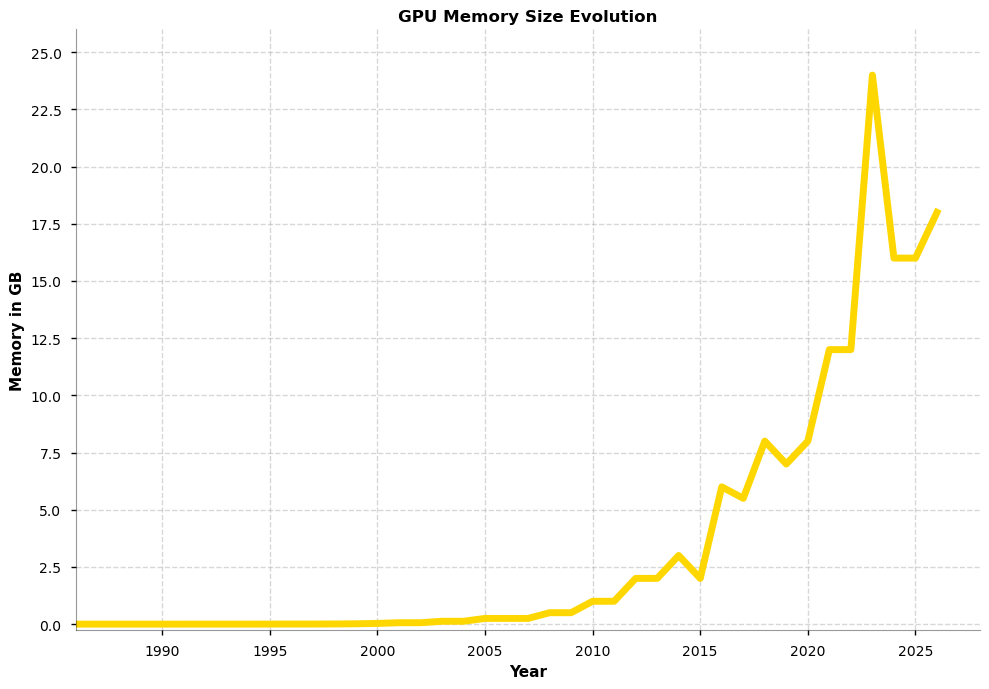

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))

# median for every year
x = df_avg_memory["Year"]
y = df_avg_memory["Memory_inGB"]
ax.plot(
    x,
    y,
    color="gold",
    linewidth=5,
    label="Median"
    )

# x
ax.set_xlabel(
    "Year",
    weight="bold"
)
ax.set_xlim(
    1986,2028
)
ax.set_xticks(
    np.arange(
        1990,2026,5
    )
)

# y
ax.set_ylabel(
    "Memory in GB",
    weight="bold"
)
ax.set_ylim(
    -0.25,26
)
ax.set_yticks(
    np.arange(
        0,25.1,2.5
    )
)

# style
ax.grid(
    True,
    linestyle="--",
    alpha=.5
)
ax.set_title(
    "GPU Memory Size Evolution",
    weight="bold"
)
ax.spines["top"].set_visible(0)
ax.spines["right"].set_visible(0)
ax.spines["bottom"].set_alpha(.4)
ax.spines["left"].set_alpha(.4)

plt.tight_layout()
# plt.savefig("../charts/memory.png", dpi=300, bbox_inches="tight")
plt.show()